In [1]:
%run SSRtransforms_updated.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML" 
workspace = "/workspace/alvin/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [29]:
# def read_mstar_clutter(filepath):
#     with open(filepath, 'rb') as f:
#         raw = f.read()
    
#     header_length = int(raw[:2000].decode('ascii', errors='ignore')
#                         .split('PhoenixHeaderLength=')[1].split()[0])
#     header = raw[:header_length].decode('ascii', errors='ignore')
#     lines = header.splitlines()
    
#     def get_field(name):
#         return [l for l in lines if name in l][0].split('=')[1].strip()
    
#     rows = int(get_field('NumberOfRows'))
#     cols = int(get_field('NumberOfColumns'))
#     native_header_length = int(get_field('native_header_length'))  # = 512
    
#     # data starts at phlen + nhlen, not just phlen
#     data_offset = header_length + native_header_length
    
#     data = np.frombuffer(raw[data_offset:], dtype='>u2')
#     magnitude = data[:rows*cols].reshape(rows, cols).astype(np.float32)
    
#     return magnitude

def read_mstar_clutter_complex(filepath):
    with open(filepath, 'rb') as f:
        raw = f.read()
    
    header_length = int(raw[:2000].decode('ascii', errors='ignore')
                        .split('PhoenixHeaderLength=')[1].split()[0])
    header = raw[:header_length].decode('ascii', errors='ignore')
    lines = header.splitlines()
    
    def get_field(name):
        return [l for l in lines if name in l][0].split('=')[1].strip()
    
    rows = int(get_field('NumberOfRows'))
    cols = int(get_field('NumberOfColumns'))
    native_header_length = int(get_field('native_header_length'))
    
    data_offset = header_length + native_header_length
    n_pixels = rows * cols
    
    data = np.frombuffer(raw[data_offset:], dtype='>u2')
    magnitude = data[:n_pixels].reshape(rows, cols).astype(np.float32)
    phase     = data[n_pixels:2*n_pixels].reshape(rows, cols).astype(np.float32)
    
    # reconstruct complex from polar form
    complex_data = magnitude * np.exp(1j * phase)
    
    return complex_data

In [32]:
read_mstar_clutter(
    os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG/HB06277")
)

array([[ 91.,  91.,  43., ...,  16.,  18.,  17.],
       [138., 140.,  71., ...,  18.,  17.,  12.],
       [128.,  99.,  59., ...,   3.,  22.,  32.],
       ...,
       [ 55.,  16.,  13., ...,  14.,   2.,  22.],
       [ 40.,   3.,  16., ...,   3.,  10.,   2.],
       [ 21.,  18.,  22., ...,  21.,   5.,  19.]],
      shape=(1784, 1478), dtype=float32)

In [34]:
read_mstar_clutter_complex(
    os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG/HB06277")
)

array([[ -14.066694 +89.90622j   ,  -88.408394 -21.562838j  ,
         -39.173256 -17.732904j  , ...,    9.112041 +13.151833j  ,
          11.029728 -14.224806j  ,   -6.525713 +15.697614j  ],
       [-119.01896  +69.84617j   , -134.08205  +40.27413j   ,
          53.102142 +47.12921j   , ...,   16.936821  +6.0945964j ,
          10.170947 +13.621741j  ,   -9.453688  +7.391061j  ],
       [ 117.96919  +49.67161j   ,   -5.6659355-98.83773j   ,
         -40.11095  -43.267902j  , ...,   -1.8998877 -2.3217292j ,
         -20.769182  +7.255416j  ,   17.046576 +27.081623j  ],
       ...,
       [  -4.6359415+54.80427j   ,  -12.065921 +10.507785j  ,
          -6.9288187+10.999612j  , ...,   11.81169   +7.5155816j ,
          -1.7675858 -0.93575674j,  -19.882364  +9.417622j  ],
       [ -19.164852 -35.109947j  ,   -2.5461893 +1.5864806j ,
          -1.4815378-15.93126j   , ...,    2.3631437 -1.8481214j ,
          -1.8915902 +9.819465j  ,    0.9744806 -1.7465359j ],
       [ -20.900415  -2.0427

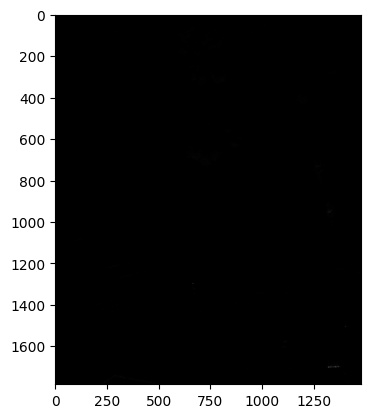

In [5]:
plt.imshow(read_mstar_clutter(
    os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG/HB06277")
), cmap='gray')

In [36]:
log_mapper = LogMapping(c = 1000.0)

In [35]:
test_clutter = np.abs(read_mstar_clutter_complex(
        os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG/HB06158")
))

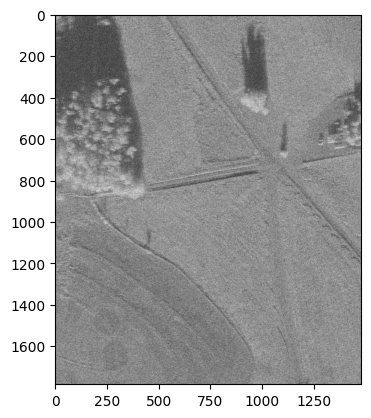

In [37]:
plt.imshow(log_mapper(test_clutter), cmap = "gray")

In [38]:
test_clutter_clipped = np.clip(test_clutter, 0, np.percentile(test_clutter, 95))

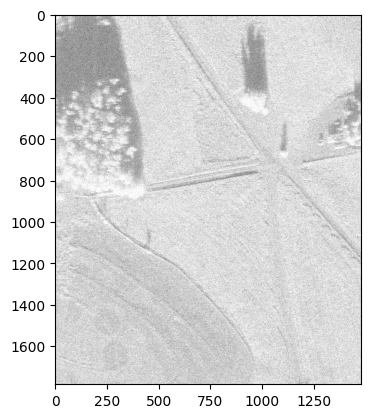

In [39]:
plt.imshow(log_mapper(test_clutter_clipped), cmap = "gray")

In [40]:
clutter_files = [os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG", f) for f in sorted(
    os.listdir(os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG"))) ]

In [41]:
def random_clutter_crop(clutter_image, crop_size=128, 
                         zero_threshold=0.9, shadow_threshold=0.3,
                         max_attempts=100):
    H, W = clutter_image.shape
    for _ in range(max_attempts):
        r = np.random.randint(0, H - crop_size)
        c = np.random.randint(0, W - crop_size)
        crop = clutter_image[r:r+crop_size, c:c+crop_size]
        # reject dead zones
        if (crop > 0).mean() < zero_threshold:
            continue
        # reject shadow-dominated regions (too many low value pixels)
        if (crop < np.percentile(clutter_image, 25)).mean() > shadow_threshold:
            continue
        return crop, r, c
    raise ValueError("Could not find valid clutter crop")

In [13]:
r_clutter = random.choices(clutter_files, k = 1385)

In [14]:
clutter_crop_ls = []
for clutter_file in tqdm(r_clutter, desc = "Cropping clutter"):
    C_full = read_mstar_clutter(clutter_file)
    # C_full_clipped = np.clip(C_full, 0, np.percentile(C_full, 95))
    C_full_log = log_mapper(C_full)
    C, r, c = random_clutter_crop(C_full_log)
    clutter_crop_ls.append(C)

Cropping clutter: 100%|███████████████████████████████████████████████████████████████| 1385/1385 [01:27<00:00, 15.87it/s]


In [15]:
meas_ds_s2 = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform=transforms.Compose([Magnitude(), LogMapping(c=1000.0)]),
    loader=mat_file_loader
)

In [16]:
t_mask, s_mask, c_mask = choi_segmentation(meas_ds_s2[0][0][0])

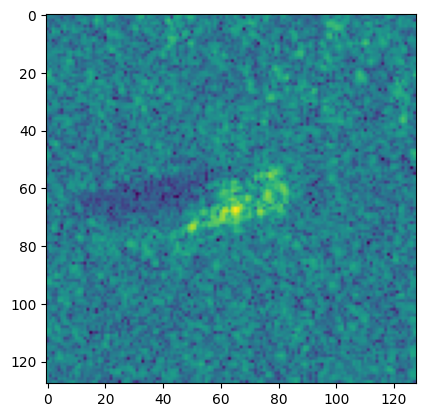

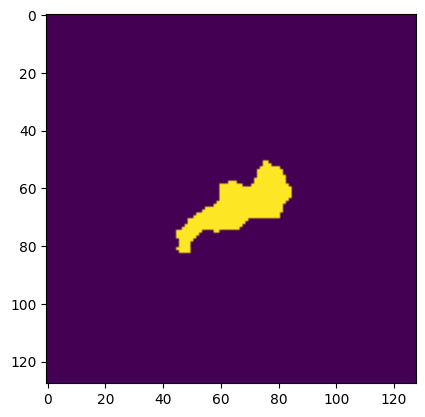

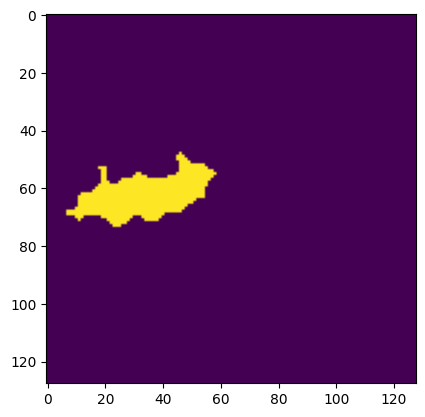

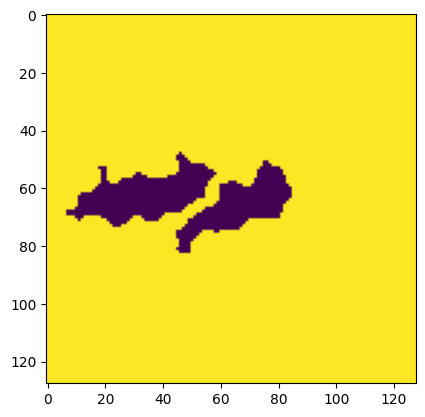

In [17]:
plt.imshow(meas_ds_s2[0][0][0])
plt.show()
plt.imshow(t_mask)
plt.show()
plt.imshow(s_mask)
plt.show()
plt.imshow(c_mask)
plt.show()

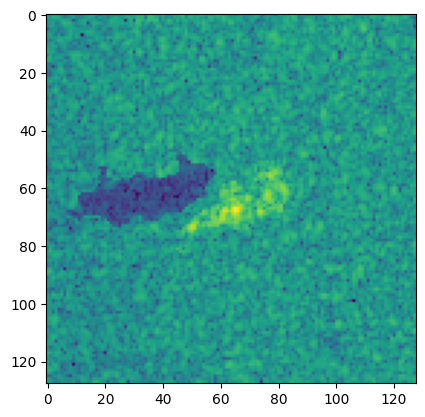

In [22]:
C = clutter_crop_ls[0]
I_meas = meas_ds_s2[0][0][0]
M_target, M_shadow, M_clutter = t_mask, s_mask, c_mask 

C_bar = (C * M_clutter).sum() / (M_clutter.sum())
I_meas_bar = (I_meas * M_clutter).sum() / (M_clutter.sum())
d = C_bar - I_meas_bar
I_merged = (I_meas + d) * M_target + I_meas * M_shadow + C * M_clutter
# I_merged = (I_meas + d) * (M_target + M_shadow) + C * M_clutter
I_merged = I_merged.astype(np.float32)
plt.imshow(I_merged)
plt.show()

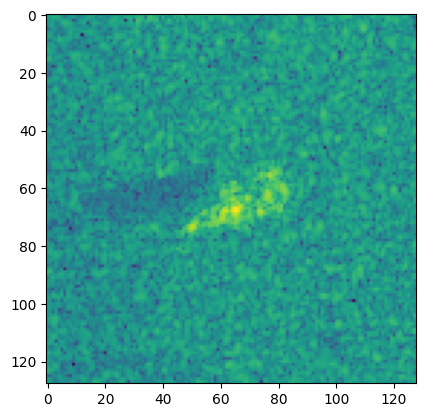

In [23]:
C = clutter_crop_ls[0]
I_meas = meas_ds_s2[0][0][0]
M_target, M_shadow, M_clutter = t_mask, s_mask, c_mask 

C_bar = (C * M_clutter).sum() / (M_clutter.sum())
I_meas_bar = (I_meas * M_clutter).sum() / (M_clutter.sum())
d = C_bar - I_meas_bar
# I_merged = (I_meas + d) * M_target + I_meas * M_shadow + C * M_clutter
I_merged = (I_meas + d) * (M_target + M_shadow) + C * M_clutter
I_merged = I_merged.astype(np.float32)
plt.imshow(I_merged)
plt.show()